In [1]:
from pycaret.regression import load_model, predict_model
import pandas as pd
from ax.service.managed_loop import optimize
import numpy as np
from ax.service.ax_client import AxClient
from ax.service.utils.instantiation import ObjectiveProperties

In [2]:
# 1. pycaret에서 기존에 구축한 모델 불러오기
model_R = load_model('et_saved_220525_test3')
model_P = load_model('et2_saved_220525_test3')
model_V = load_model('et3_saved_220525_test3')

# Load the test data from CSV into a DataFrame
# test_df = pd.read_csv('Test_data_ML-R9_220516_test3_MW.csv', encoding='cp949')

# input data 불러오기
input_df = pd.read_csv('Bays_data_initial 10_251007.csv', encoding='cp949')

# base와 columns 정의
base = input_df.iloc[0].copy()
columns = input_df.columns

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [3]:
# 이전 논문에서 정의한 obj 값 구현
def pycaret_predict(params):
    # 파라미터 매핑
    param_map = {
        "Feed_rate_SLPM": "Feed rate (SLPM)",
        "Rinse_rate_SLPM": "Rinse rate (SLPM)",
        "Pad_bar": "Pad (bar)",
        "Pde_bar": "Pde (bar)"
    }
    updated_base = base.copy()
    for k, v in params.items():
        updated_base[param_map[k]] = v
    input_row_updated = {col: updated_base[col] for col in columns}
    input_df_pred = pd.DataFrame([input_row_updated])

    # 모델 예측
    pred_R = predict_model(model_R, data=input_df_pred)
    pred_P = predict_model(model_P, data=input_df_pred)
    pred_V = predict_model(model_V, data=input_df_pred)

    # obj 계산 (이전 논문 참조)
    Feed_CO = 0.2 * input_df_pred['Feed rate (SLPM)'] * 60 / (10**3 * 0.082057 * 273.15)
    Product_CO = Feed_CO * pred_R['prediction_label'] / 100
    Productivity = Product_CO*10**3*24/(4*578.36/10**3)

    k_comp = 1.4 * (0.517 + 0.253) + 1.28 * 0.23
    k_vc = 1.4
    mu = 0.75
    Feed_Compressor = 2.78e-4 * k_comp / (k_comp - 1) * 100 * input_df_pred['Pad (bar)'] / mu / mu / input_df_pred['Pad (bar)'] ** ((k_comp - 1) / k_comp - 1)
    Rinse_Compressor = 2.78e-4 * k_vc / (k_vc - 1) * 100 * input_df_pred['Pad (bar)'] / mu / mu / input_df_pred['Pad (bar)'] ** ((k_vc - 1) / k_vc - 1)
    Vacuum_Pump = 2.78e-4 * k_vc / (k_vc - 1) * 100 * mu / mu / (1 / input_df_pred['Pde (bar)']) ** ((k_vc - 1) / k_vc - 1)
    Electricity = Feed_Compressor + Rinse_Compressor * (input_df_pred['Rinse rate (SLPM)'] / input_df_pred['Feed rate (SLPM)']) + Vacuum_Pump * (pred_V['prediction_label'] / input_df_pred['Feed rate (SLPM)'])

    CO_Low = (pred_P['prediction_label'] / 100) * (2411 / 11000) * 0.528
    CO_High = 15.49008 * np.exp(0.75093 * (pred_P['prediction_label'] - 98))
    CO_Price = np.maximum(CO_Low, CO_High)

    Fee_gas = (20 / 100) * (2411 / 11000) * 0.528
    Elec_price = 0.1
    Propit = CO_Price * Product_CO * 22.4
    Cost = input_df_pred['Feed rate (SLPM)'] * (60 / 10**3) * Fee_gas
    Opex = (60 / 10**3) * input_df_pred['Feed rate (SLPM)'] * Electricity * Elec_price

    obj = Propit - Cost - Opex
    # 예측값과 obj를 반환하도록 수정
    return {
        'obj': obj.iloc[0],
        'pred_R': pred_R['prediction_label'].iloc[0],
        'pred_P': pred_P['prediction_label'].iloc[0],
        'pred_V': pred_V['prediction_label'].iloc[0],
        'Productivity': Productivity.iloc[0]
    }

In [ ]:
# base와 columns 정의
base = input_df.iloc[0].copy()
columns = input_df.columns

# 결과 저장용 리스트
history = []

def evaluation_function(params):
    result = pycaret_predict(params)
    row = {
        **params,
        'pred_R': result['pred_R'],
        'pred_P': result['pred_P'],
        'pred_V': result['pred_V'],
        'obj': result['obj'],
        'Productivity': result['Productivity']
    }
    history.append(row)
    return {'obj': result['obj']} # 기존 v5.5에서는 return {'pred_R': result['pred_R'], 'pred_P': result['pred_P']}

# AxClient 생성 및 실험 정의
ax_client = AxClient()
ax_client.create_experiment(
    name="psa_optimization",
    parameters=[
        {"name": "Feed_rate_SLPM", "type": "range", "bounds": [2, 8], "value_type": "float"},
        {"name": "Rinse_rate_SLPM", "type": "range", "bounds": [0.8, 2.1], "value_type": "float"},
        {"name": "Pad_bar", "type": "range", "bounds": [2.5, 6.4], "value_type": "float"},
        {"name": "Pde_bar", "type": "range", "bounds": [0.05, 0.15], "value_type": "float"},
    ],
    objectives={
    'obj': ObjectiveProperties(minimize=False),  # 수익 극대화
    # 기존 v5.5에서는 "pred_R": ObjectiveProperties(minimize=False),  # 예: 회수율 ≥ XX 이상
    #  기존 v5.5에서는 "pred_P": ObjectiveProperties(minimize=False), # 예: 순도 ≥ 0.XX 이상
    }
)

# 실험 반복
for i in range(50):
    parameters, trial_index = ax_client.get_next_trial()
    obj_result = evaluation_function(parameters)
    ax_client.complete_trial(trial_index=trial_index, raw_data=obj_result)

# 결과 DataFrame 생성
history_df = pd.DataFrame(history)
print(history_df.head())

# 최적 파라미터 및 값 출력
# best_parameters, values = ax_client.get_best_parameters()
pareto_optimal = ax_client.get_pareto_optimal_parameters()
print("Pareto optimal parameters:")
for idx, (params, values) in enumerate(pareto_optimal.items()):
	print(f"Solution {idx + 1}:")
	print(f"  Parameters: {params}")
	print(f"  Objective values: {values}")

# Ax 내장 분석 시각화
ax_client.compute_analyses(display=True)

[INFO 01-22 14:12:21] ax.generation_strategy.dispatch_utils: Using Generators.BOTORCH_MODULAR since there is at least one ordered parameter and there are no unordered categorical parameters.
[INFO 01-22 14:12:21] ax.generation_strategy.dispatch_utils: Using Bayesian Optimization generation strategy: GenerationStrategy(name='Sobol+BoTorch', steps=[Sobol for 8 trials, BoTorch for subsequent trials]). Iterations after 8 will take longer to generate due to model-fitting.
[INFO 01-22 14:12:21] ax.service.ax_client: Generated new trial 0 with parameters {'Feed_rate_SLPM': 7.21267, 'Rinse_rate_SLPM': 1.240703, 'Pad_bar': 5.598245, 'Pde_bar': 0.086738} using model Sobol.
[INFO 01-22 14:12:21] ax.service.ax_client: Completed trial 0 with data: {'obj': -0.18945}.
[INFO 01-22 14:12:21] ax.service.ax_client: Generated new trial 1 with parameters {'Feed_rate_SLPM': 4.915136, 'Rinse_rate_SLPM': 1.800643, 'Pad_bar': 3.762937, 'Pde_bar': 0.146885} using model Sobol.
[INFO 01-22 14:12:22] ax.service.ax

In [5]:
from datetime import datetime
import os

# Summary 테이블을 CSV로 저장

# 현재 시간 정보 가져오기
current_time = datetime.now().strftime('%Y%m%d_%H%M%S')

ipynb_filename = '251110_PSA_Bayesian_optimization_v5.5'

# CSV 파일명 생성
csv_filename = f'{current_time}_{ipynb_filename}_Summary_for_psa_optimization.csv'

# history_df를 CSV로 저장
history_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')

print(f'Summary table saved as: {csv_filename}')

Summary table saved as: 20251110_140022_251110_PSA_Bayesian_optimization_v5.5_Summary_for_psa_optimization.csv


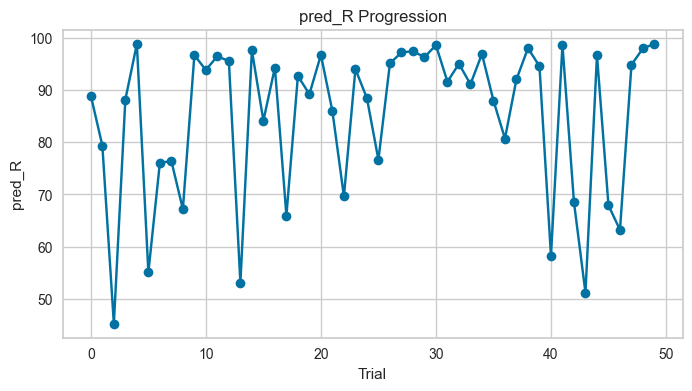

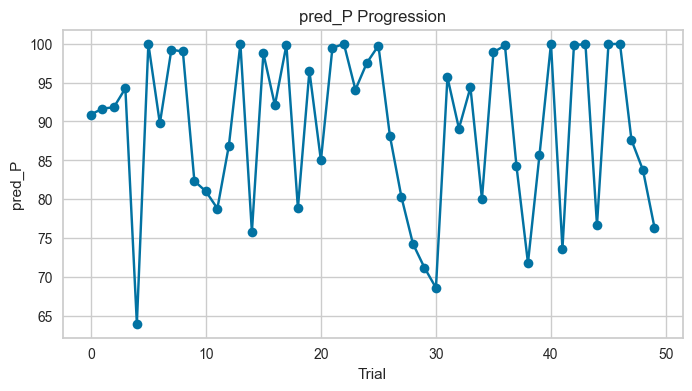

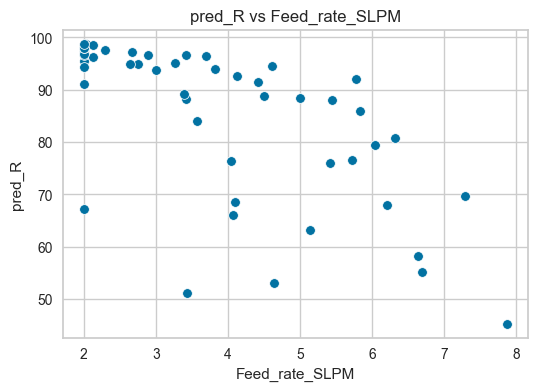

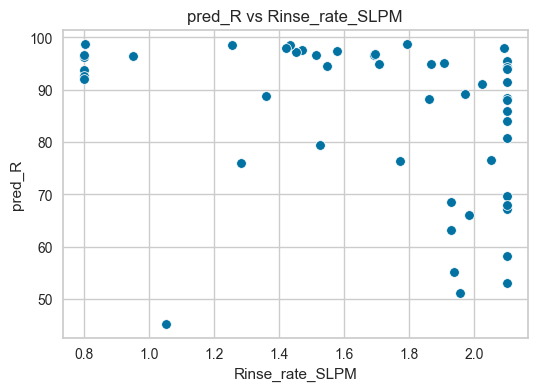

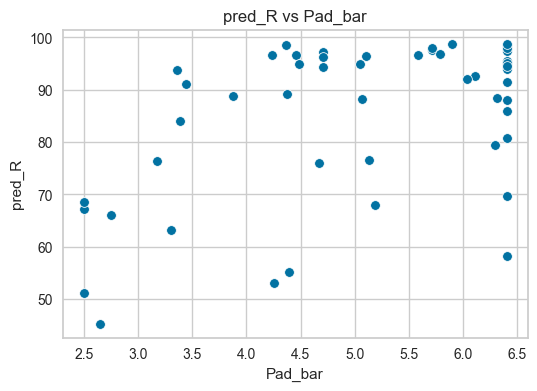

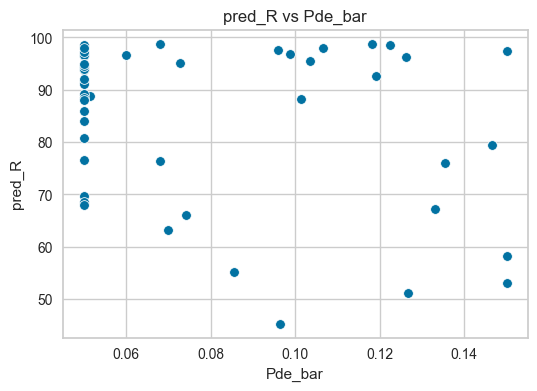

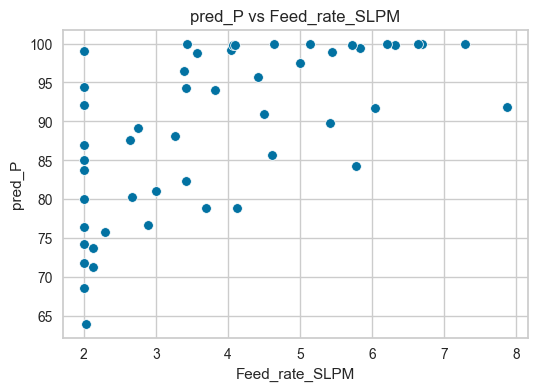

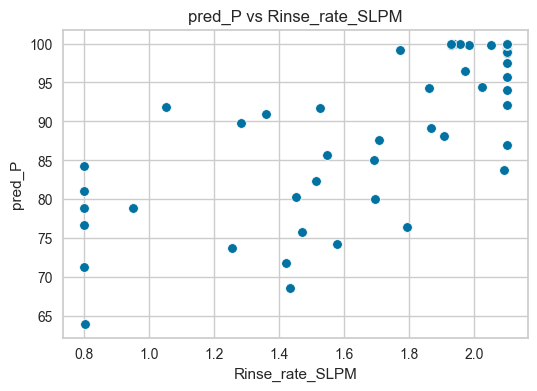

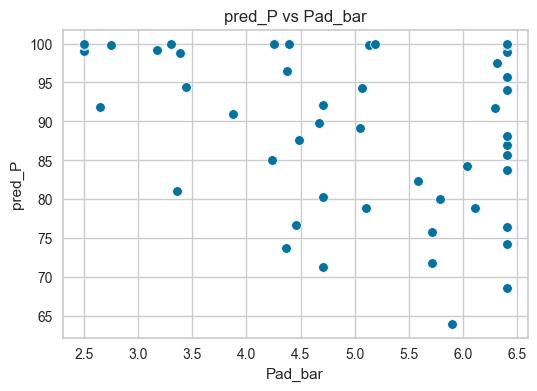

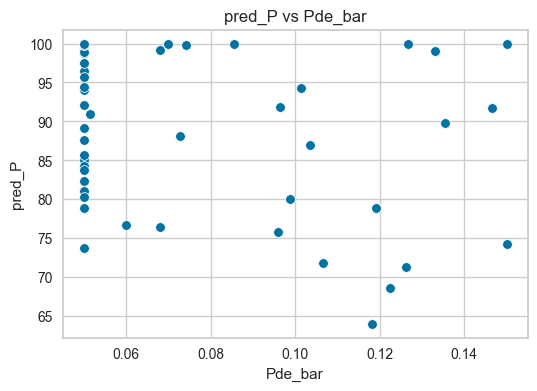

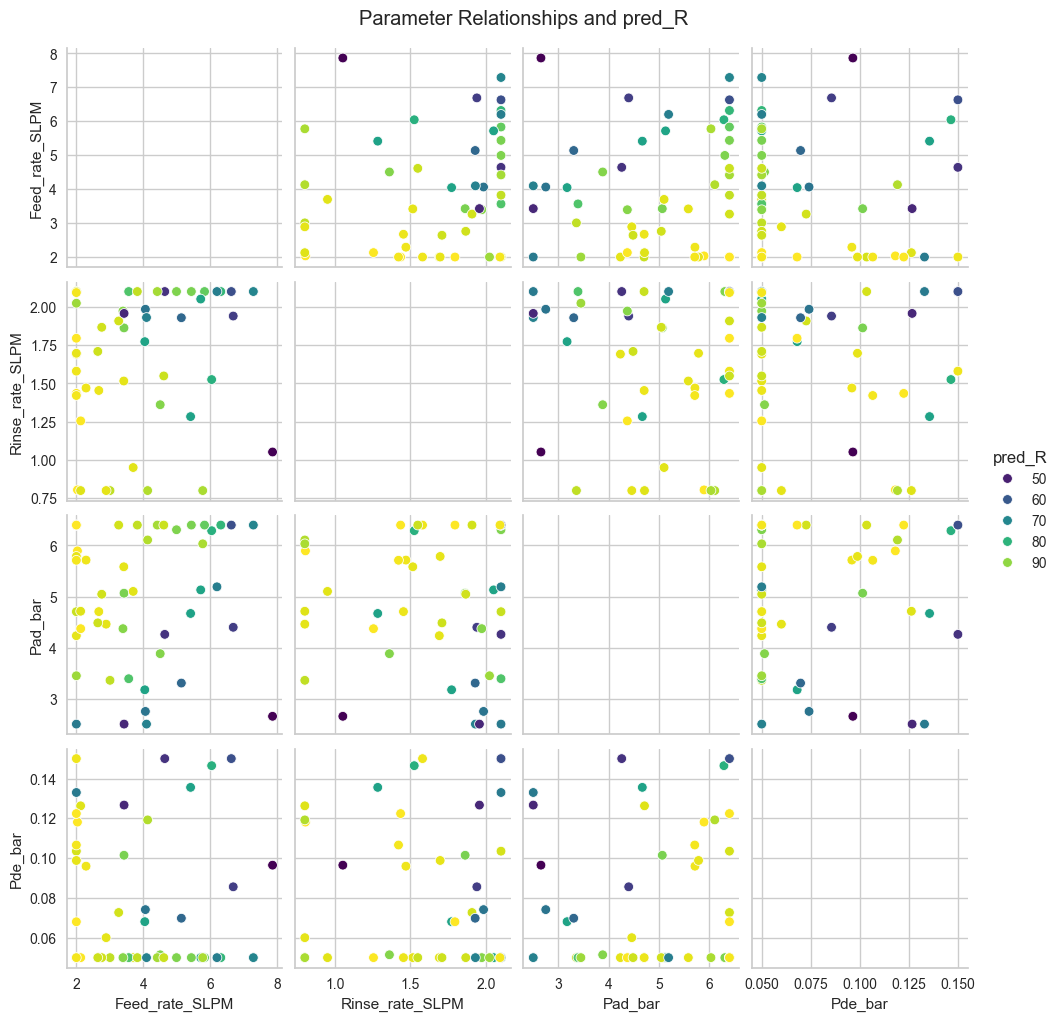

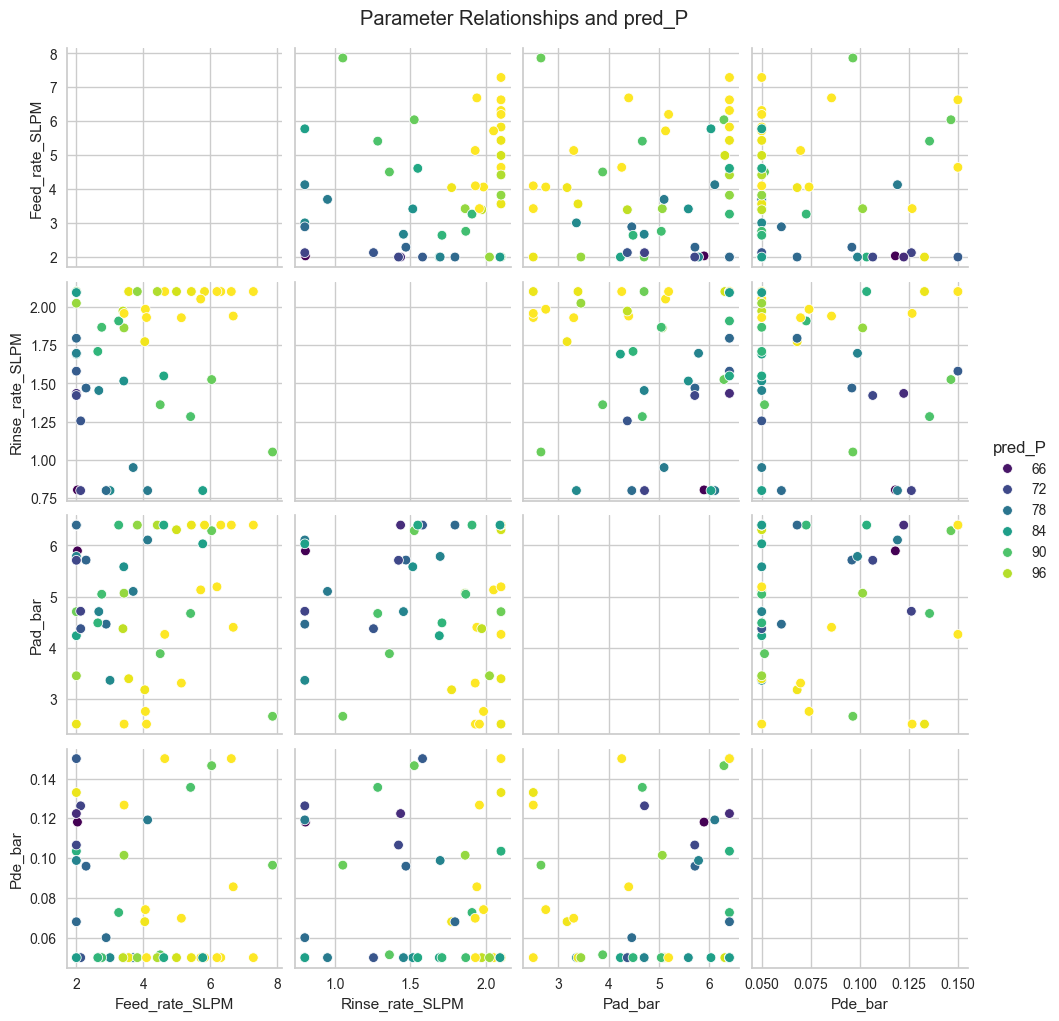

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 각 Objective 값의 변화 추이
objectives = ['pred_R', 'pred_P']
for obj in objectives:
    plt.figure(figsize=(8,4))
    plt.plot(history_df[obj], marker='o')
    plt.xlabel('Trial')
    plt.ylabel(obj)
    plt.title(f'{obj} Progression')
    plt.show()

# 2. 파라미터별 각 Objective 값 분포
param_names = ['Feed_rate_SLPM', 'Rinse_rate_SLPM', 'Pad_bar', 'Pde_bar']
for obj in objectives:
    for param in param_names:
        plt.figure(figsize=(6,4))
        sns.scatterplot(data=history_df, x=param, y=obj)
        plt.title(f'{obj} vs {param}')
        plt.show()

# 3. Pairplot (Objective별 색상)
for obj in objectives:
    sns.pairplot(history_df, vars=param_names, hue=obj, palette='viridis')
    plt.suptitle(f'Parameter Relationships and {obj}', y=1.02)
    plt.show()
